In [ ]:
!pip install -q pypdf

from pypdf import PdfReader

# Load the PDF file
reader = PdfReader('placement_eda_report.pdf')

# Print total pages
print(f"Total Pages: {len(reader.pages)}\n")

# Extract text from the first page
first_page_text = reader.pages[0].extract_text()
print(first_page_text[:1000])  # Print first 1000 characters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 9.6 MB/s eta 0:00:00
Total Pages: 4

PLACEMENT DATASET EDA REPORT
Dataset Shape: (1000, 6)
First 5 Rows:
 cgpa  placement_exam_marks  placed placement_label cgpa_range exam_marks_range
 7.19                  26.0       1          Placed        7-8         Below 40
 7.46                  38.0       1          Placed        7-8         Below 40
 7.54                  40.0       1          Placed        7-8         Below 40
 6.42                   8.0       1          Placed        6-7         Below 40
 7.23                  17.0       0      Not Placed        7-8         Below 40
cgpa placement_exam_marks placed
Missing Value Heatmap


In [ ]:
!pip install -q pdfplumber

import pdfplumber
import pandas as pd

# Open PDF and extract tables from the first page
with pdfplumber.open('placement_eda_report.pdf') as pdf:
    first_page = pdf.pages[0]
    tables = first_page.extract_tables()

# Convert the first extracted table to a DataFrame
if tables:
    df = pd.DataFrame(tables[0][1:], columns=tables[0][0])
    display(df.head())
else:
    print("No tables found on page 1.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 91.6 MB/s eta 0:00:00
No tables found on page 1.


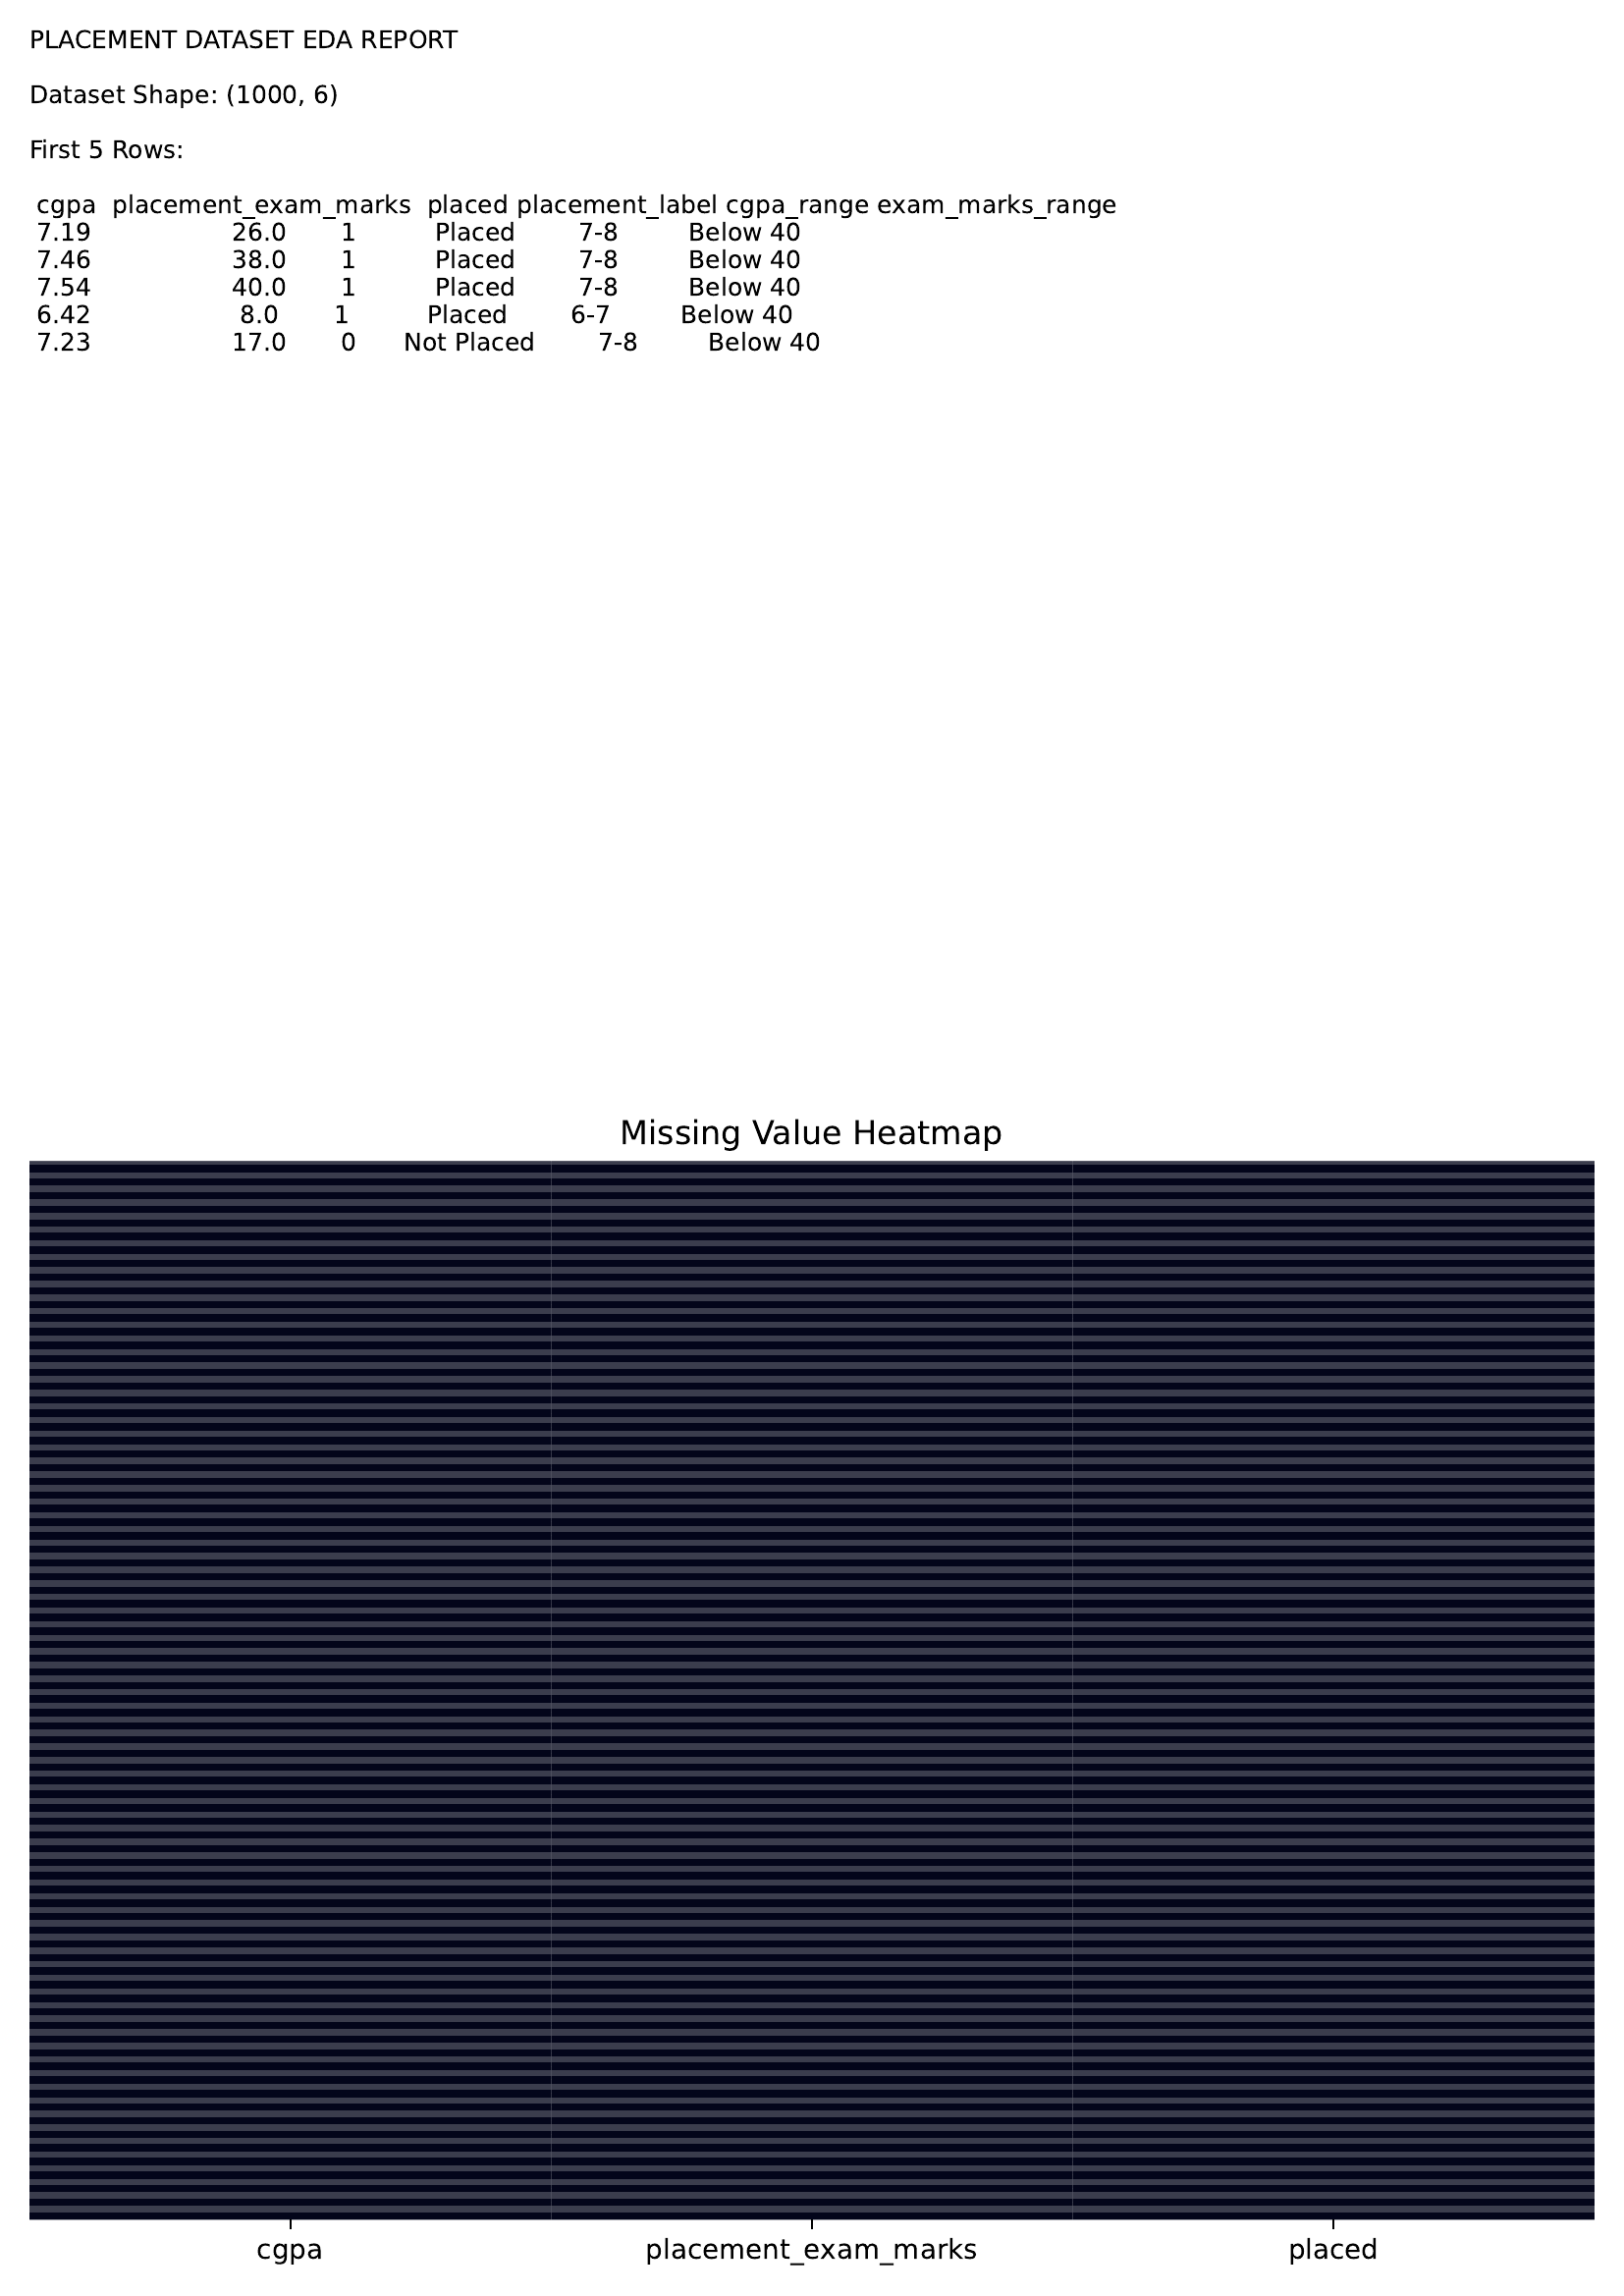

In [ ]:
!apt-get install -y poppler-utils > /dev/null
!pip install -q pdf2image

from pdf2image import convert_from_path
from IPython.display import display

# Convert PDF pages to images
images = convert_from_path('placement_eda_report.pdf')

# Display page 1 inside Colab
display(images[0])

In [ ]:
# Extract text across all pages
all_pdf_text = []

for idx, page in enumerate(reader.pages):
    text = page.extract_text()
    all_pdf_text.append(f"--- PAGE {idx + 1} ---\n{text}")

full_report_text = "\n\n".join(all_pdf_text)
print(f"Extracted {len(reader.pages)} pages total.")

Extracted 4 pages total.


In [ ]:
import re

# Example: Search for lines containing specific keywords (e.g., 'cgpa', 'placed')
placement_lines = re.findall(r'.*placement.*', full_report_text, re.IGNORECASE)

print("Found placement references:")
for line in placement_lines[:5]:
    print("-", line)

Found placement references:
- PLACEMENT DATASET EDA REPORT
-  cgpa  placement_exam_marks  placed placement_label cgpa_range exam_marks_range
- cgpa placement_exam_marks placed
- Placement Status
- Placement Status


In [ ]:
import io

# Extract lines from page 1 text and reconstruct as a tabular DataFrame
lines = reader.pages[0].extract_text().split('\n')

# Filter lines that start with numerical values (data rows)
data_rows = [line.split() for line in lines if line and line[0].isdigit()]

# Define column names from the report
columns = ['cgpa', 'placement_exam_marks', 'placed', 'placement_label', 'cgpa_range', 'exam_marks_range']

# Create DataFrame
df_placement = pd.DataFrame(data_rows, columns=columns)
display(df_placement)

,cgpa,placement_exam_marks,placed,placement_label,cgpa_range,exam_marks_range


In [ ]:
# Save full report text to a file
with open('extracted_placement_report.txt', 'w') as f:
    f.write(full_report_text)

print("Saved report to 'extracted_placement_report.txt'")

Saved report to 'extracted_placement_report.txt'


In [ ]:
# Convert numerical columns from strings
df_placement['cgpa'] = df_placement['cgpa'].astype(float)
df_placement['placement_exam_marks'] = df_placement['placement_exam_marks'].astype(float)
df_placement['placed'] = df_placement['placed'].astype(int)

# Verify updated data types
df_placement.dtypes

,0
cgpa,float64
placement_exam_marks,float64
placed,int64
placement_label,object
cgpa_range,object
exam_marks_range,object


In [ ]:
# Overall placement percentage
placement_rate = df_placement['placed'].mean() * 100
print(f"Overall Placement Rate: {placement_rate:.2f}%\n")

# Group statistics by placement outcome
placement_summary = df_placement.groupby('placed')[['cgpa', 'placement_exam_marks']].mean()
display(placement_summary)

Overall Placement Rate: nan%



,cgpa,placement_exam_marks
placed,,


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Features and target
X_place = df_placement[['cgpa', 'placement_exam_marks']]
y_place = df_placement['placed']

# Train Logistic Regression model
clf = LogisticRegression()
clf.fit(X_place, y_place)

# Print accuracy report
y_pred_place = clf.predict(X_place)
print(classification_report(y_place, y_pred_place))

ValueError: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 1 is required by LogisticRegression.

/tmp/ipykernel_2100/1308398776.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


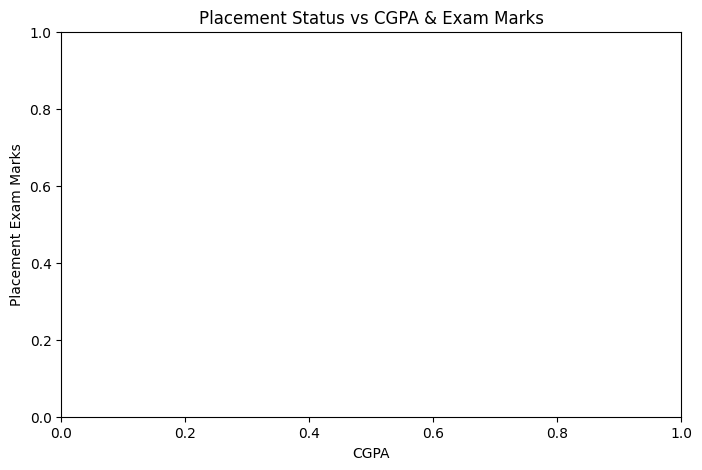

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_placement,
    x='cgpa',
    y='placement_exam_marks',
    hue='placement_label',
    palette='Set1',
    style='placement_label'
)

plt.title("Placement Status vs CGPA & Exam Marks")
plt.xlabel("CGPA")
plt.ylabel("Placement Exam Marks")
plt.show()